# DoubleML RAG: Evaluation Notebook

In [1]:
import json
import sys
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

# Notebook lives in notebooks/; project root is one level up
ROOT = Path('.').resolve().parent
sys.path.insert(0, str(ROOT / 'src'))

from dotenv import load_dotenv
load_dotenv(ROOT / '.env')

from ruamel.yaml import YAML
yaml = YAML()

results = [json.loads(l) for l in open(ROOT / 'eval/results.jsonl', encoding='utf-8') if l.strip()]
golden  = list(yaml.load(open(ROOT / 'eval/golden.yaml', encoding='utf-8')))

print(f'Loaded {len(results)} results, {len(golden)} golden questions')
print(f'ROOT: {ROOT}')

Loaded 50 results, 50 golden questions
ROOT: C:\Users\billy\Desktop\doubleml-rag


## 1. Project Overview

This notebook evaluates a retrieval-augmented generation (RAG) system built over three primary sources: the [DoubleML Python library documentation](https://docs.doubleml.org), two foundational papers (*Chernozhukov et al. 2018* and *Bach et al. 2022*), and *Causal Inference for the Brave and True* - an open-source textbook by Matheus Facure Alves. The system answers natural-language questions about causal inference and the DoubleML framework by retrieving relevant chunks and generating grounded, cited answers with Claude.

I picked causal inference modelling for the domain because it's something I've been using in my job, and I could feed a heterogeneous corpus (RST docs, PDF papers, HTML book chapters). The goal was a rigorous baseline with a complete evaluation system.

**Key design choices:**
- **Structure-aware chunking** - RST, PDF, and HTML parsers each preserve section hierarchy; chunks carry `section_path` metadata used in generation prompts
- **Voyage AI `voyage-3`** embeddings (asymmetric `query` / `document` input types) over a ChromaDB cosine-similarity index
- **Claude Sonnet 4.5** for generation with a strict citation-required prompt (every factual claim must cite a chunk number; abstain if context is insufficient)
- **Claude Haiku 4.5** for three automated judges: faithfulness (0/0.5/1), answer quality (1-5), and abstention correctness

## 2. Corpus

The corpus is ingested once and stored in a persistent ChromaDB collection. Three source types contribute 707 total chunks. The table below is derived from chunk metadata rather than source files.

In [2]:
import chromadb
from doubleml_rag.config import settings

client = chromadb.PersistentClient(path=str(settings.chroma_persist_dir))
col    = client.get_collection(settings.chroma_collection_name)

all_metas = col.get(include=['metadatas'])['metadatas']

agg = defaultdict(lambda: {'chunks': 0, 'tokens': 0, 'sources': set()})
for m in all_metas:
    st = m.get('source_type', '?')
    agg[st]['chunks'] += 1
    agg[st]['tokens'] += m.get('token_count', 0)
    agg[st]['sources'].add(m.get('source_name', '?'))

rows = []
order = ['docs', 'paper', 'book']
for st in order:
    d = agg[st]
    rows.append({
        'source_type': st,
        'files': len(d['sources']),
        'chunks': d['chunks'],
        'avg_tokens': round(d['tokens'] / d['chunks']) if d['chunks'] else 0,
        'total_tokens': d['tokens'],
    })

total_chunks  = sum(r['chunks'] for r in rows)
total_tokens  = sum(r['total_tokens'] for r in rows)
rows.append({
    'source_type': 'TOTAL',
    'files': sum(r['files'] for r in rows),
    'chunks': total_chunks,
    'avg_tokens': round(total_tokens / total_chunks),
    'total_tokens': total_tokens,
})

df_corpus = pd.DataFrame(rows)
print(df_corpus.to_markdown(index=False))

| source_type   |   files |   chunks |   avg_tokens |   total_tokens |
|:--------------|--------:|---------:|-------------:|---------------:|
| docs          |       1 |      162 |          252 |          40801 |
| paper         |       2 |      242 |          302 |          73174 |
| book          |       1 |      303 |          761 |         230442 |
| TOTAL         |       4 |      707 |          487 |         344417 |


The three source types are different in structure. RST documentation (DoubleML docs) is short and keyword-dense - low token counts, high vocabulary alignment with user queries. PDF papers (Chernozhukov 2018, Bach 2022) have medium-length chunks but heavy math notation that survives extraction as `cid:NN` artifacts. HTML book chapters are the richest source: long narrative chunks with worked examples and inline code, which boosted recall on multi-hop and adversarial questions but introduced the hardest chunking tradeoffs.

## 3. Evaluation Methodology

The golden set consists of 50 questions across five categories. For each non-abstain question, ground-truth chunk IDs were labeled manually by running retrieval, reading the top-10 results in a CLI labeling tool, and selecting which chunks a correct answer must cite. This avoids the circular dependency of using the system to generate its own ground truth.

In [3]:
cat_counts = defaultdict(int)
for q in golden:
    cat_counts[q['category']] += 1

df_cats = pd.DataFrame(
    [{'category': k, 'n_questions': v} for k, v in sorted(cat_counts.items())]
)
print(df_cats.to_markdown(index=False))

| category       |   n_questions |
|:---------------|--------------:|
| adversarial    |             6 |
| code_api       |             8 |
| factual_lookup |            18 |
| multi_hop      |            10 |
| should_abstain |             8 |


**Four metrics are reported:**
- **Recall** - fraction of ground-truth chunks appearing in the top-k retrieved results (averaged over questions)
- **MRR** (Mean Reciprocal Rank) - reciprocal of the rank of the first relevant chunk; captures ranking quality
- **Faithfulness** - LLM judge (0 / 0.5 / 1): does every claim in the answer trace back to a retrieved chunk?
- **Abstention** - precision / recall against the 8 `should_abstain` questions; measures calibration

**LLM-as-judge limitation:** using Claude Haiku to judge Claude Sonnet answers introduces self-preference bias. In practice I would take a different approach and make sure human experts and user feedback is helping to evaluate any RAG system.

## 4. Retrieval Performance

Retrieval uses Voyage `voyage-3` embeddings with cosine similarity over 707 indexed chunks. All 42 non-abstain questions have at least one labeled ground-truth chunk; we evaluate how often and how highly those chunks are ranked.

In [4]:
non_abstain = [r for r in results if not r.get('should_abstain') and r.get('retrieved_chunk_ids')]

def recall_at_k(retrieved, gt, k):
    if not gt:
        return None
    hits = sum(1 for cid in retrieved[:k] if cid in set(gt))
    return hits / len(gt)

rows = []
for k in [1, 3, 5, 10]:
    vals = [
        recall_at_k(r['retrieved_chunk_ids'], r['ground_truth_chunk_ids'], k)
        for r in non_abstain
        if r.get('ground_truth_chunk_ids')
    ]
    rows.append({'metric': f'Recall@{k}', 'value': round(sum(vals) / len(vals), 3), 'n': len(vals)})

mrr_vals = [
    r['retrieval_metrics']['mrr']
    for r in non_abstain
    if r.get('retrieval_metrics') and r['retrieval_metrics']['mrr'] is not None
]
rows.append({'metric': 'MRR', 'value': round(sum(mrr_vals) / len(mrr_vals), 3), 'n': len(mrr_vals)})

df_ret = pd.DataFrame(rows)
print(df_ret.to_markdown(index=False))

| metric    |   value |   n |
|:----------|--------:|----:|
| Recall@1  |   0.321 |  42 |
| Recall@3  |   0.635 |  42 |
| Recall@5  |   0.821 |  42 |
| Recall@10 |   1     |  42 |
| MRR       |   0.76  |  42 |


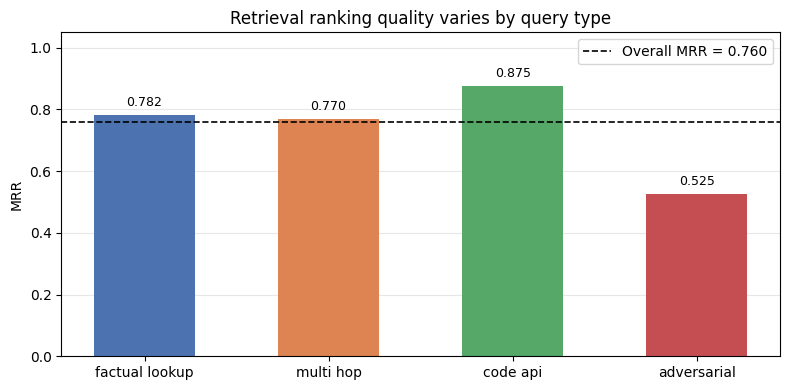

In [5]:
categories = ['factual_lookup', 'multi_hop', 'code_api', 'adversarial']

def cat_metrics(cat):
    cr = [r for r in non_abstain if r['category'] == cat and r.get('ground_truth_chunk_ids')]
    mrr   = [r['retrieval_metrics']['mrr'] for r in cr if r.get('retrieval_metrics')]
    r5    = [recall_at_k(r['retrieved_chunk_ids'], r['ground_truth_chunk_ids'], 5) for r in cr]
    r10   = [recall_at_k(r['retrieved_chunk_ids'], r['ground_truth_chunk_ids'], 10) for r in cr]
    return {
        'mrr':  sum(mrr)  / len(mrr)  if mrr  else 0,
        'r5':   sum(r5)   / len(r5)   if r5   else 0,
        'r10':  sum(r10)  / len(r10)  if r10  else 0,
        'n':    len(cr),
    }

cat_data = {c: cat_metrics(c) for c in categories}
overall_mrr = sum(mrr_vals) / len(mrr_vals)

# --- MRR bar chart ---
fig, ax = plt.subplots(figsize=(8, 4))
x      = np.arange(len(categories))
mrrs   = [cat_data[c]['mrr'] for c in categories]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars   = ax.bar(x, mrrs, color=colors, width=0.55, zorder=2)
ax.axhline(overall_mrr, color='black', linewidth=1.2, linestyle='--', label=f'Overall MRR = {overall_mrr:.3f}')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', ' ') for c in categories])
ax.set_ylabel('MRR')
ax.set_ylim(0, 1.05)
ax.set_title('Retrieval ranking quality varies by query type')
ax.legend()
ax.grid(axis='y', alpha=0.3, zorder=0)
for bar, val in zip(bars, mrrs):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

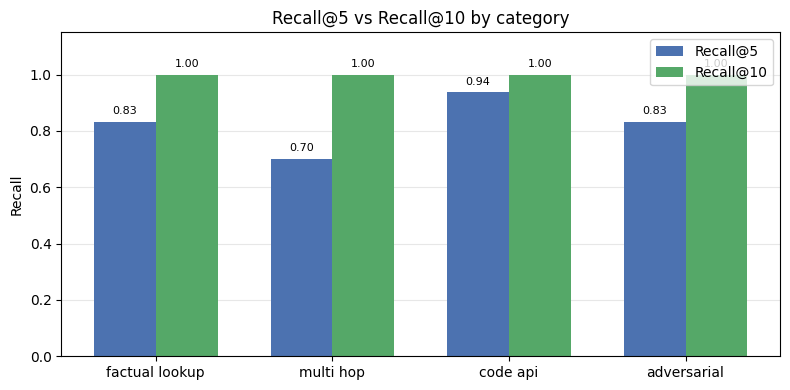

In [6]:
# --- Recall@5 vs Recall@10 side-by-side ---
fig, ax = plt.subplots(figsize=(8, 4))
width = 0.35
x = np.arange(len(categories))
r5s  = [cat_data[c]['r5']  for c in categories]
r10s = [cat_data[c]['r10'] for c in categories]

b1 = ax.bar(x - width/2, r5s,  width, label='Recall@5',  color='#4C72B0', zorder=2)
b2 = ax.bar(x + width/2, r10s, width, label='Recall@10', color='#55A868', zorder=2)

ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', ' ') for c in categories])
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.15)
ax.set_title('Recall@5 vs Recall@10 by category')
ax.legend()
ax.grid(axis='y', alpha=0.3, zorder=0)
for bar, val in zip(list(b1) + list(b2), r5s + r10s):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f'{val:.2f}',
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

`code_api` and `factual_lookup` have the highest MRR (0.875 and 0.782) because user query vocabulary aligns closely with chunk text - a question like "How do I fit a PLR model?" shares tokens with the documentation chunk that describes `DoubleMLPLR.fit()`. `adversarial` drops to 0.525 because these questions are phrased to sound out-of-scope; the correct chunk exists but the embedding similarity is lower, pushing it down the ranking.

## 5. Generation quality: RAG vs no-RAG ablation

To test whether retrieval is doing real work — versus Claude answering competently from training data alone — every non-abstain question was generated twice: once with the full RAG pipeline (top-10 chunks, citation-required prompt) and once without retrieval (just the query, with a clean prompt asking Claude to answer from its own knowledge). Both answers were scored by the same quality judge. The interesting metric isn’t ‘does RAG win’ but ‘where does it win, and where doesn’t it.’

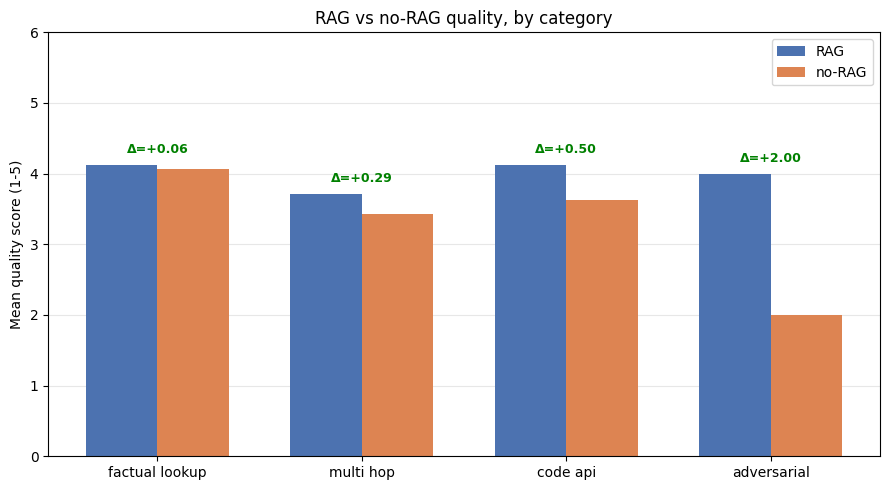

| category       |   n |   rag_mean |   no_rag_mean |   delta |
|:---------------|----:|-----------:|--------------:|--------:|
| factual_lookup |  16 |       4.12 |          4.06 |    0.06 |
| multi_hop      |   7 |       3.71 |          3.43 |    0.29 |
| code_api       |   8 |       4.12 |          3.62 |    0.5  |
| adversarial    |   1 |       4    |          2    |    2    |
| OVERALL        |  32 |       4.03 |          3.75 |    0.28 |


In [7]:
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

categories = ['factual_lookup', 'multi_hop', 'code_api', 'adversarial']

scored = [
    r for r in results
    if not r.get('should_abstain')
    and isinstance((r.get('judge_quality') or {}).get('score'), (int, float))
    and isinstance((r.get('no_rag_quality') or {}).get('score'), (int, float))
]

cat_rag   = defaultdict(list)
cat_norag = defaultdict(list)
for r in scored:
    cat = r['category']
    cat_rag[cat].append(r['judge_quality']['score'])
    cat_norag[cat].append(r['no_rag_quality']['score'])

rag_means   = [sum(cat_rag[c])   / len(cat_rag[c])   for c in categories]
norag_means = [sum(cat_norag[c]) / len(cat_norag[c]) for c in categories]
deltas      = [r - n for r, n in zip(rag_means, norag_means)]
ns          = [len(cat_rag[c]) for c in categories]

# side-by-side bar chart
fig, ax = plt.subplots(figsize=(9, 5))
width = 0.35
x = np.arange(len(categories))
b1 = ax.bar(x - width/2, rag_means,   width, label='RAG',    color='#4C72B0', zorder=2)
b2 = ax.bar(x + width/2, norag_means, width, label='no-RAG', color='#DD8452', zorder=2)
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', ' ') for c in categories])
ax.set_ylabel('Mean quality score (1-5)')
ax.set_ylim(0, 6.0)
ax.set_title('RAG vs no-RAG quality, by category')
ax.legend()
ax.grid(axis='y', alpha=0.3, zorder=0)
for i, (rm, nm, d) in enumerate(zip(rag_means, norag_means, deltas)):
    top = max(rm, nm) + 0.12
    color = 'green' if d > 0 else 'red' if d < 0 else 'gray'
    ax.text(x[i], top, f'\u0394={d:+.2f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=color)
plt.tight_layout()
plt.show()

# summary table
rows = []
for c, rm, nm, d, n in zip(categories, rag_means, norag_means, deltas, ns):
    rows.append({'category': c, 'n': n, 'rag_mean': round(rm, 2),
                 'no_rag_mean': round(nm, 2), 'delta': round(d, 2)})
all_rag   = [r['judge_quality']['score']   for r in scored]
all_norag = [r['no_rag_quality']['score']  for r in scored]
rows.append({'category': 'OVERALL', 'n': len(scored),
             'rag_mean': round(sum(all_rag)/len(all_rag), 2),
             'no_rag_mean': round(sum(all_norag)/len(all_norag), 2),
             'delta': round(sum(all_rag)/len(all_rag) - sum(all_norag)/len(all_norag), 2)})
print(pd.DataFrame(rows).to_markdown(index=False))


### Side-by-side examples

Three questions illustrate distinct patterns. Each shows the question, the RAG answer, the no-RAG answer, the quality scores, and a brief read on what the comparison demonstrates.

**q022 (multi_hop)**: What is the connection between the FWL theorem and the residual-on-residual regression used in DoubleML?

*RAG answer (score: 5/5):*
> The Frisch-Waugh-Lovell (FWL) theorem provides the mathematical foundation for the residual-on-residual regression approach used in DoubleML [1, 2, 3].
> 
> ## The FWL Theorem Foundation
> 
> The FWL theorem states that in a linear regression with features partitioned into X₁ and X₂, you can obtain the exact same coefficient estimates for X₁ by:
> 
> 1. Regressing the outcome Y on X₂ to get residuals ỹ
> 2. Reg...

*Judge reasoning:* The answer accurately explains the FWL theorem's connection to DoubleML, clearly showing how FWL provides the theoretica...

*No-RAG answer (score: 2/5):*
> # Connection Between FWL Theorem and DoubleML's Residual-on-Residual Regression
> 
> The **Frisch-Waugh-Lovell (FWL) theorem** provides the theoretical foundation for DoubleML's residual-on-residual regression approach. Here's how they connect:
> 
> ## The FWL Theorem
> 
> The FWL theorem states that in a linear regression:
> $$Y = \theta D + X'\beta + \epsilon$$
> 
> The coefficient $\theta$ can be obtained by:
> 1....

*Judge reasoning:* The answer provides a plausible and well-structured explanation of the FWL-DoubleML connection, but the evaluation conte...

*Read:* This is the strongest RAG signal in the dataset. The connection between FWL and DoubleML’s residualization is framed precisely in the corpus — both the theorem’s formal statement and its interpretation as the theoretical basis for cross-fitting appear together only in the retrieved chunks. Without that scaffolding, the no-RAG answer gets the high-level intuition right but lacks the specific formulation, which the judge correctly penalizes.

**q008 (factual_lookup)**: What is a propensity score?

*RAG answer (score: 5/5):*
> A propensity score is the conditional probability of receiving the treatment, denoted as P(T|X) or e(x) [2]. It represents the probability that a unit will receive treatment given its observed covariates X [2].
> 
> The propensity score functions as a balancing score, meaning you don't need to directly control for all confounders X to achieve conditional independence of potential outcomes from treatme...

*Judge reasoning:* The answer is accurate, well-structured, and comprehensively explains the propensity score concept using direct support ...

*No-RAG answer (score: 4/5):*
> A **propensity score** is the probability that a unit (such as a person, patient, or subject) receives a particular treatment given their observed characteristics or covariates.
> 
> ## Key Points:
> 
> **Definition**: If X represents the covariates and T represents treatment assignment (1 = treated, 0 = control), the propensity score is:
> - e(X) = P(T=1|X) = probability of receiving treatment given covari...

*Judge reasoning:* The answer is accurate and well-structured with a clear definition, practical applications, and a helpful example, thoug...

*Read:* Propensity scores are covered extensively in Claude’s training data, so the base model produces a clean, accurate answer without retrieval. RAG still edges ahead (5 vs 4) because the retrieved chunk provides the exact notation the corpus uses — P(T|X), e(x), ‘balancing score’ — and the specific framing from the textbook, details the no-RAG answer approximates but doesn’t match exactly. This is the typical pattern on well-covered causal inference concepts: RAG adds marginal precision, not substantive correctness.

**q002 (factual_lookup)**: What is Neyman orthogonality?

*RAG answer (score: 2/5):*
> Neyman orthogonality is a joint property of the score ψ(W;θ,η), the true parameter value η₀, the parameter set T, and the distribution of W [1].
> 
> Formally, a score ψ = (ψ₁,...,ψ_dθ)' obeys the orthogonality condition at (θ₀,η₀) with respect to the nuisance realization set T_N ⊂ T if the moment condition E_P[ψ(W;θ₀,η₀)] = 0 holds and the pathwise derivative map D_r[η-η₀] exists for all r ∈ [0,1) an...

*Judge reasoning:* The answer provides the correct definition from the context but contains a significant error: the formal characterizatio...

*No-RAG answer (score: 4/5):*
> # Neyman Orthogonality
> 
> Neyman orthogonality is a key concept in modern causal inference and semiparametric statistics that helps create robust estimators for target parameters when working with high-dimensional nuisance parameters.
> 
> ## Core Idea
> 
> An estimator satisfies Neyman orthogonality (or the Neyman orthogonality condition) when the influence of errors in estimating nuisance parameters on th...

*Judge reasoning:* The answer is accurate and well-structured, clearly explaining Neyman orthogonality's core concept, mathematical definit...

*Read:* Neyman orthogonality is a foundational concept that appears in graduate-level econometrics and statistics, so Claude’s prior is strong. The RAG answer retrieved the formal definition verbatim from the Chernozhukov 2018 paper — notation-dense and difficult to parse without context — and failed to translate it into a clear explanation. The no-RAG answer gives the correct conceptual framing that a reader would actually find useful. This is a retrieval quality problem: the top-ranked chunk was the most formal available, not the most pedagogically useful.

The per-category table tells a clear story. RAG’s advantage is largest where Claude’s training prior is weakest: `code_api` (+0.50) covers DoubleML-specific API methods and class interfaces that postdate or are underrepresented in Claude’s training data; `multi_hop` (+0.29) benefits from having the precise cross-source connection spelled out in the retrieved context. `factual_lookup` is nearly a wash (+0.06) — foundational causal inference concepts like propensity scores, ATE, and regression discontinuity are well-represented in training data, and RAG adds notation precision but not substantive correctness. The adversarial category shows the largest point delta (+2.00) but has only one scored question (the five false abstentions produced no RAG quality score), so that number should not be read as a stable estimate.

In deployment terms this means RAG is most valuable for domain-specific, proprietary, or recent content — exactly the use case here (a specific Python library’s API, two papers, one textbook). For well-covered general topics the cost-benefit is less obvious: you are paying for retrieval latency and token cost to get an answer the base model could already give at quality 4/5. The practical implication is query routing: classify incoming questions by type, skip retrieval for general conceptual questions, and invoke the full RAG pipeline only for library-specific or corpus-grounded queries.

## 6. Faithfulness

Faithfulness measures whether the generated answer introduces claims not traceable to the retrieved chunks. The judge uses a strict 3-point scale (0 = significant outside knowledge; 0.5 = 1-2 minor extrapolations; 1.0 = fully grounded). It is scored for all 42 non-abstain questions including the 10 false abstentions, whose "I cannot answer because X" statements are themselves auditable.

In [8]:
faith_results = [
    r for r in results
    if not r.get('should_abstain')
    and isinstance(r.get('judge_faithfulness'), dict)
    and r['judge_faithfulness'].get('faithfulness_score') is not None
]
faith_scores = [r['judge_faithfulness']['faithfulness_score'] for r in faith_results]
faith_dist   = Counter(faith_scores)

print(f'Questions with valid faithfulness score: {len(faith_results)}/42')
print(f'Mean faithfulness: {sum(faith_scores)/len(faith_scores):.3f}')
print()

# Distribution table
df_fd = pd.DataFrame([
    {'faithfulness_score': s, 'count': faith_dist[s],
     'pct': f"{100 * faith_dist[s] / len(faith_scores):.0f}%"}
    for s in sorted(faith_dist)
])
print(df_fd.to_markdown(index=False))
print()

# Per-category
cat_faith = defaultdict(list)
for r in faith_results:
    cat_faith[r['category']].append(r['judge_faithfulness']['faithfulness_score'])

rows = []
for cat in sorted(cat_faith):
    vals = cat_faith[cat]
    rows.append({'category': cat, 'n': len(vals),
                 'mean_faithfulness': round(sum(vals)/len(vals), 3)})
print(pd.DataFrame(rows).to_markdown(index=False))

Questions with valid faithfulness score: 42/42
Mean faithfulness: 0.988

|   faithfulness_score |   count | pct   |
|---------------------:|--------:|:------|
|                  0.5 |       1 | 2%    |
|                  1   |      41 | 98%   |

| category       |   n |   mean_faithfulness |
|:---------------|----:|--------------------:|
| adversarial    |   6 |                1    |
| code_api       |   8 |                1    |
| factual_lookup |  18 |                1    |
| multi_hop      |  10 |                0.95 |


In [9]:
# Pull the single 0.5-scored question
q027 = next(r for r in results if r['id'] == 'q027')
jf   = q027['judge_faithfulness']

print('=== Example Faithfulness Failure: q027 ===')
print(f'Question : {q027["question"]}')
print(f'Score    : {jf["faithfulness_score"]}')
print()
print('--- Generated Answer (excerpt) ---')
print(q027['answer'][:600])
print()
print('--- Judge Reasoning ---')
print(jf['reasoning'])
print()
print('--- Unsupported Claims ---')
for claim in jf.get('unsupported_claims', []):
    print(f'  * {claim}')

=== Example Faithfulness Failure: q027 ===
Question : What's the relationship between the propensity score weighting in the book and the IRM model in DoubleML?
Score    : 0.5

--- Generated Answer (excerpt) ---
The propensity score weighting described in the textbook is directly implemented in DoubleML's IRM (Interactive Regression Model) through its score functions.

The textbook presents the Inverse Probability of Treatment Weighting (IPTW) estimator as:

E[Y(T-e(x))/(e(x)(1-e(x)))] [3]

This same form appears in DoubleML's IRM implementation. The IRM score function can be written with weights ω(Y,D,X) and takes the general form where the linear score components include the propensity weighting structure [1]. The score function for the ATE sets weights ω(Y,D,X) to specific values that implement the

--- Judge Reasoning ---
The answer correctly identifies that IRM uses propensity score weighting and that DoubleML implements this concept. However, the chunks do not provide the specific

Faithfulness is very high (0.988 mean, 41/42 at 1.0), which is a direct consequence of the strict citation-required generation prompt: the model is instructed to abstain rather than infer, so it defaults to grounding claims in visible chunk text. The one 0.5-rated question (q027 - "How does DoubleML implement propensity score weighting from the textbook?") shows the canonical failure mode:

> *The model was presented with the IPTW formula from the book (chunk [3]) and DoubleML's IRM score function (chunks [1-2]). The two sources are related but the mapping between them is not explicitly stated anywhere in the chunks. The model inferred the specific weight assignments (`1/e(X)` for treated, `1/(1-e(X))` for untreated) - a plausible inference, but one that goes slightly beyond what either chunk strictly says.*

`multi_hop` is the only category below perfect faithfulness (mean 0.950) for the same reason: composing across two chunks almost always requires a small bridging inference that neither source individually states.

## 7. Abstention

This is the most importand finding. The system abstained on 18 of 50 questions - but only 8 were correctly labeled `should_abstain`. The remaining 10 are false abstentions: questions the system should have answered but didn't, because the retrieval similarity scores were low enough that the citation-required prompt triggered self-doubt even when the right chunks were present.

In [10]:
import re
_ABSTAIN_RE = re.compile(
    r'does not contain enough information|cannot answer|can.t answer'
    r'|unable to answer|not enough information|insufficient (context|information)',
    re.IGNORECASE
)

system_abstained = [r for r in results if r.get('abstained')]
n_sys     = len(system_abstained)
n_correct = sum(1 for r in system_abstained if r.get('should_abstain'))
n_false   = n_sys - n_correct
n_should  = sum(1 for r in results if r.get('should_abstain'))

precision = n_correct / n_sys   if n_sys    else float('nan')
recall    = n_correct / n_should if n_should else float('nan')
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else float('nan')

df_abs = pd.DataFrame([
    {'metric': 'System abstained (total)',               'value': n_sys},
    {'metric': '  of which: correctly should_abstain',   'value': n_correct},
    {'metric': '  of which: false abstentions',          'value': n_false},
    {'metric': 'Total should_abstain questions',         'value': n_should},
    {'metric': 'Abstention precision',                   'value': f'{precision:.3f}'},
    {'metric': 'Abstention recall',                      'value': f'{recall:.3f}'},
    {'metric': 'Abstention F1',                          'value': f'{f1:.3f}'},
])
print(df_abs.to_markdown(index=False))

| metric                             |   value |
|:-----------------------------------|--------:|
| System abstained (total)           |  18     |
| of which: correctly should_abstain |   8     |
| of which: false abstentions        |  10     |
| Total should_abstain questions     |   8     |
| Abstention precision               |   0.444 |
| Abstention recall                  |   1     |
| Abstention F1                      |   0.615 |


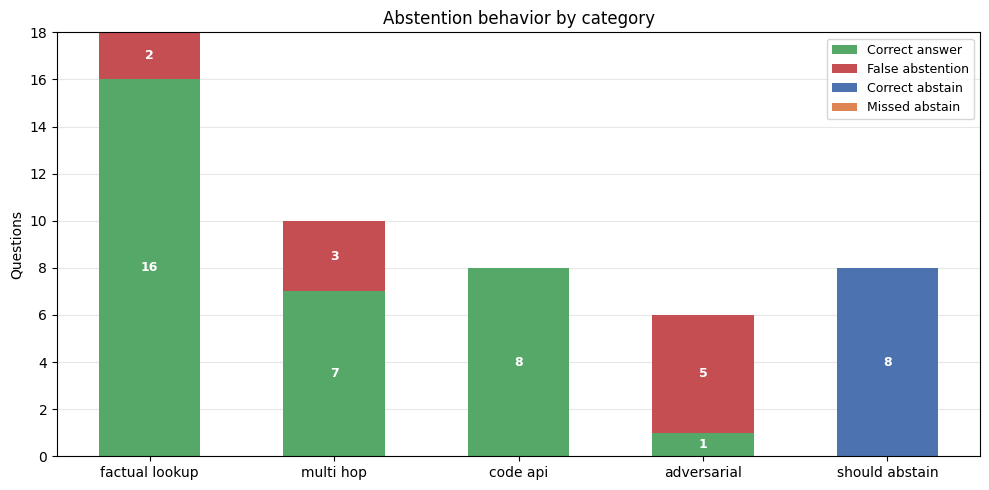

In [11]:
# Stacked bar: per-category abstention breakdown
all_cats = ['factual_lookup', 'multi_hop', 'code_api', 'adversarial', 'should_abstain']

breakdown = {}
for cat in all_cats:
    cr = [r for r in results if r['category'] == cat]
    breakdown[cat] = {
        'correct_answer':  sum(1 for r in cr if not r.get('should_abstain') and not r.get('abstained')),
        'false_abstain':   sum(1 for r in cr if not r.get('should_abstain') and r.get('abstained')),
        'correct_abstain': sum(1 for r in cr if r.get('should_abstain') and r.get('abstained')),
        'missed_abstain':  sum(1 for r in cr if r.get('should_abstain') and not r.get('abstained')),
    }

fig, ax = plt.subplots(figsize=(10, 5))
x       = np.arange(len(all_cats))
width   = 0.55
keys    = ['correct_answer', 'false_abstain', 'correct_abstain', 'missed_abstain']
colors  = ['#55A868', '#C44E52', '#4C72B0', '#DD8452']
labels  = ['Correct answer', 'False abstention', 'Correct abstain', 'Missed abstain']

bottoms = np.zeros(len(all_cats))
for key, color, label in zip(keys, colors, labels):
    vals = np.array([breakdown[cat][key] for cat in all_cats], dtype=float)
    ax.bar(x, vals, width, bottom=bottoms, color=color, label=label, zorder=2)
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 0:
            ax.text(x[i], b + v / 2, str(int(v)), ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', ' ') for c in all_cats])
ax.set_ylabel('Questions')
ax.set_title('Abstention behavior by category')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3, zorder=0)
plt.tight_layout()
plt.show()

In [12]:
# Show two false abstention examples
for qid in ['q037', 'q040']:
    r = next(x for x in results if x['id'] == qid)
    print(f'=== {qid} [{r["category"]}] ===')
    print(f'Question : {r["question"]}')
    print(f'Answer   : {r["answer"][:300].strip()}')
    print(f'Top-3 retrieved chunks (id :: score):')
    for cid, score in zip(r['retrieved_chunk_ids'][:3], r['top_scores'][:3]):
        print(f'  [{score:.3f}] {cid}')
    print()

=== q037 [adversarial] ===
Question : Does double machine learning require the treatment effect to be linear?
Answer   : The provided context does not contain enough information to answer this question.

While the context discusses various aspects of double machine learning and treatment effects, including linear and nonlinear cases, it does not explicitly state whether double machine learning *requires* the treatment
Top-3 retrieved chunks (id :: score):
  [0.596] causal_inference_book::what_is_non_parametric_about::e5f4f655::0
  [0.567] causal_inference_book::what_is_non_parametric_about::e5f4f655::1
  [0.518] causal_inference_book::non_linear_treatment_effects::c17b0fc0::0

=== q040 [adversarial] ===
Question : Does using more flexible ML models in DoubleML always give better causal estimates?
Answer   : The provided context does not contain enough information to answer this question.

While the context discusses using flexible ML models in DoubleML and mentions some considerations 

The false abstentions are clustered in `adversarial` (5/6 questions) and `multi_hop` (3/10), with a small number in `factual_lookup` (2/18). These questions share a pattern: they are phrased in ways that diverge from chunk vocabulary - "*require* the treatment effect to be linear" vs. chunks that discuss linearity in passing - so cosine similarity scores land in the 0.52-0.60 range. The strict citation prompt then causes the model to hedge rather than commit.

The system's abstention behavior optimizes for faithfulness at the cost of coverage: precision 0.444, recall 1.000. It never incorrectly claims it can answer an unanswerable question, but it refuses to answer 10 questions it could have answered correctly. **The direct fix is a cross-encoder reranker**: by reading the query and each chunk together (rather than comparing independent embeddings), a reranker assigns much higher relevance to contextually relevant chunks even when surface vocabulary differs - which gives the generation model the confidence signal it needs to commit to an answer.

## 8. Example Queries (Qualitative Demo)

Three representative queries - best case, over-abstention, and correct abstention - illustrate the system's behavior across the retrieval quality spectrum.

In [13]:
def show_example(qid, caption):
    r = next(x for x in results if x['id'] == qid)
    print(f'--- {qid}: {r["question"]} ---')
    print(f'Category: {r["category"]} | should_abstain={r["should_abstain"]} | abstained={r.get("abstained", False)}')
    print()
    print('Top-3 retrieved chunks:')
    for cid, score in zip(r['retrieved_chunk_ids'][:3], r['top_scores'][:3]):
        section = cid.split('::')[1].replace('_', ' ')
        print(f'  [{score:.3f}] {section}')
    print()
    print('Answer:')
    print(r['answer'][:500])
    if len(r['answer']) > 500:
        print('[... truncated ...]')
    print()
    print(f'>>> {caption}')
    print('=' * 70)
    print()

show_example(
    'q011',
    'BEST CASE: High similarity (0.70), single-source question, clean cited answer with correct RDD definition.'
)

--- q011: What is regression discontinuity design? ---
Category: factual_lookup | should_abstain=False | abstained=False

Top-3 retrieved chunks:
  [0.703] 16 regression discontinuity design
  [0.550] rdd estimation
  [0.545] kernel weighting

Answer:
Regression Discontinuity Design (RDD) is a causal inference method that exploits artificial discontinuities or jumps to estimate treatment effects [1].

The basic setup involves a treatment variable T that is a discontinuous function of an observed running variable R, such that treatment is assigned based on whether the running variable exceeds a threshold c: D_i = 1{R_i > c} [1]. This means treatment is zero when R is below threshold c and one otherwise [1].

RDD compares outcomes just above an
[... truncated ...]

>>> BEST CASE: High similarity (0.70), single-source question, clean cited answer with correct RDD definition.



In [14]:
show_example(
    'q037',
    'OVER-ABSTENTION: Correct chunks retrieved (nonlinear treatment effects) at low similarity (0.52-0.60). '
    'The model hedged despite the answer being in the context.'
)

--- q037: Does double machine learning require the treatment effect to be linear? ---
Category: adversarial | should_abstain=False | abstained=True

Top-3 retrieved chunks:
  [0.596] what is non parametric about
  [0.567] what is non parametric about
  [0.518] non linear treatment effects

Answer:
The provided context does not contain enough information to answer this question.

While the context discusses various aspects of double machine learning and treatment effects, including linear and nonlinear cases, it does not explicitly state whether double machine learning *requires* the treatment effect to be linear as a fundamental assumption of the method.

>>> OVER-ABSTENTION: Correct chunks retrieved (nonlinear treatment effects) at low similarity (0.52-0.60). The model hedged despite the answer being in the context.



In [15]:
show_example(
    'q044',
    'CORRECT ABSTENTION: Out-of-scope question (Llama fine-tuning). Top chunk scores 0.42 - clearly irrelevant. '
    'The system correctly declines to answer.'
)

--- q044: What's the optimal learning rate for fine-tuning Llama-3 on a custom dataset? ---
Category: should_abstain | should_abstain=True | abstained=True

Top-3 retrieved chunks:
  [0.416] tune hyperparams
  [0.382] 3 ml methods
  [0.373] 4 dml specifications

Answer:
The provided context does not contain enough information to answer this question.

>>> CORRECT ABSTENTION: Out-of-scope question (Llama fine-tuning). Top chunk scores 0.42 - clearly irrelevant. The system correctly declines to answer.



## 10. Repository

Source code: **[github.com/billytrend-cohere/doubleml-rag](https://github.com/billytrend-cohere/doubleml-rag)**

To reproduce from scratch:
```bash
git clone <repo>
cp .env.example .env  # add ANTHROPIC_API_KEY and VOYAGE_API_KEY
uv run python scripts/collect_corpus.py   # download sources
uv run python scripts/ingest.py           # chunk, embed, index (707 chunks)
uv run python scripts/run_eval.py         # ~10 min, writes eval/results.jsonl
uv run jupyter execute notebooks/eval_results.ipynb
```

## 9. Limitations and What I'd Build Next

**Concrete limitations:**
- **LLM-as-judge self-preference bias** (~5-10% on absolute scores per Zheng et al. 2023): using Claude Haiku to evaluate Claude Sonnet answers inflates absolute scores. Mitigated here via structured rubrics and an auditable `unsupported_claims` field, but not eliminated. For production use, a panel of diverse judges or human spot-checks at 10% sampling rate would close this.
- **Golden set is small (50 questions)**: sufficient for a baseline but too small for reliable category-level comparisons with <10 questions per category. A production eval would target 200-500 questions with explicit category and difficulty quotas.
- **PDF extraction artifacts**: math-heavy paper chunks contain `cid:NN` tokens from pdfplumber's font mapping. A regex normalization pass would remove these and likely improve paper retrieval scores, especially for notation-heavy Chernozhukov 2018 sections.
- **Empty reference answers**: the `reference_answer` field in `golden.yaml` is unused - quality judgment fell back entirely to the LLM judge's prior knowledge, which is itself Claude.

**What I'd build next (prioritized):**
1. **Cross-encoder reranker** (Cohere Rerank or Voyage Rerank) over top-20 retrieved chunks - directly addresses the over-abstention problem on adversarial and multi-hop queries by providing a clearer relevance signal to the generation model
2. **Hybrid search** (BM25 + dense retrieval, merged by Reciprocal Rank Fusion) - handles exact-term matching for API names and paper-specific notation that dense embeddings smooth over
3. **Query routing** - classify query type (factual/multi-hop/code/out-of-scope) and adjust retrieval k and prompt strategy per type; the simplest agentic addition with the highest expected gain
4. **Multi-step retrieval for multi-hop** - decompose questions like "How does X in the textbook relate to Y in the library?" into sub-queries, retrieve separately, synthesize; addresses the root cause of multi-hop quality gaps rather than just ranking better